### py311_env - Python environment

In [1]:
!pip install -q deepeval

In [1]:
# load environment variable from .env file
from dotenv import load_dotenv
load_dotenv()

True

In [2]:
from deepeval import evaluate
from deepeval.test_case import LLMTestCase, LLMTestCaseParams
from deepeval.metrics import GEval
from deepeval.dataset import EvaluationDataset
import pandas as pd
from deepeval.dataset import Golden

from deepeval.test_case import LLMTestCase
from deepeval.dataset import EvaluationDataset, Golden
from deepeval.metrics import AnswerRelevancyMetric, ConversationalGEval, ConversationCompletenessMetric, BiasMetric
from deepeval import evaluate

import time
import os
from deepeval.evaluate import AsyncConfig


In [3]:
# Read the CSV with proper encoding
data = pd.read_csv("data_bank/hard.csv")
data_sel = data.dropna(subset=['tursio_response']).reset_index(drop=True)   
data_sel.head()

,persona,kpi,difficulty,synthetic_questions,tursio_response
0,Risk & Credit Analytics Manager; CRO; Complian...,90+ DPD Rate; Delinquency Ratio; Non-Performin...,hard,What is the trend of 90+ DPD accounts segmente...,"Key Insights\n\nOver the last 24 months, the 9..."
1,Risk & Credit Analytics Manager; CRO; Complian...,90+ DPD Rate; Delinquency Ratio; Non-Performin...,hard,For accounts that became delinquent in the las...,"High-Impact Findings\n\nIn the last year, 100%..."
2,Risk & Credit Analytics Manager; CRO; Complian...,90+ DPD Rate; Delinquency Ratio; Non-Performin...,hard,Analyze the concentration risk by identifying ...,Key Insights:\n\nThe top 10% of borrowers driv...
3,Risk & Credit Analytics Manager; CRO; Complian...,90+ DPD Rate; Delinquency Ratio; Non-Performin...,hard,What behavioral traits or transaction patterns...,Great question but unfortunately no data point...
4,Risk & Credit Analytics Manager; CRO; Complian...,90+ DPD Rate; Delinquency Ratio; Non-Performin...,hard,How does the delinquency ratio differ across d...,Key Findings:\n\nWide Range of Delinquency Rat...


In [5]:
data_sel.shape[0]

38

In [6]:
dataset = EvaluationDataset()

# Store metadata for later use in test cases
golden_metadata = []

# Add goldens from dataframe
for idx, row in data_sel.iterrows():
    if pd.isna(row['tursio_response']):
        continue
    golden = Golden(input=row['synthetic_questions'])
    dataset.add_golden(golden)
    # Store context metadata for later use
    golden_metadata.append({
        'role': row['persona'],
        'kpi': row['kpi']
    })

In [7]:
answer_relevancy_metric = AnswerRelevancyMetric()
bias_metric = BiasMetric()

In [8]:
golden

Golden(input='Develop a risk profile for accounts that have multiple product holdings but display erratic behavior in transaction patterns over the last 6 months.', actual_output=None, expected_output=None, context=None, retrieval_context=None, additional_metadata=None, comments=None, tools_called=None, expected_tools=None, source_file=None, name=None, custom_column_key_values=None, multimodal=False, images_mapping=None)

In [9]:
idx = 0
for golden in dataset.goldens:
  if idx < len(data_sel) and idx < len(golden_metadata):
    context = [
        f"Role: {golden_metadata[idx]['role']}",
        f"KPI: {golden_metadata[idx]['kpi']}"
    ]
    dataset.add_test_case(
      LLMTestCase(
        input=golden.input,
        actual_output=data_sel.iloc[idx]['tursio_response'],
        retrieval_context=context
      )
    )
  idx += 1

print(f"Added {len(dataset.test_cases)} test cases from {len(dataset.goldens)} goldens")

Added 38 test cases from 38 goldens


In [10]:
print (dataset.test_cases[0])

input='What is the trend of 90+ DPD accounts segmented by loan type over the last 24 months, and how does it correlate with macroeconomic indicators such as unemployment and interest rates?' actual_output='Key Insights\n\nOver the last 24 months, the 90+ DPD counts show monthly fluctuations across loan types with certain loan types (e.g., 101 and 102) exhibiting larger swings in both counts and loan volumes.\nWhile the dataset provides monthly average interest rates alongside DPD counts, there is no clear, direct correlation between the interest rate changes and the frequency of 90+ DPD accounts. The macroeconomic indicator of unemployment is not present in the data, so its correlation cannot be assessed.' expected_output=None context=None retrieval_context=['Role: Risk & Credit Analytics Manager; CRO; Compliance Officer', 'KPI: 90+ DPD Rate; Delinquency Ratio; Non-Performing Loan %'] additional_metadata=None tools_called=None comments=None expected_tools=None token_cost=None completio

In [11]:
import sys
from io import StringIO
import contextlib

# Increase timeout for API calls
os.environ["DEEPEVAL_PER_ATTEMPT_TIMEOUT_SECONDS_OVERRIDE"] = "600"
os.environ["DEEPEVAL_VERBOSE"] = "false"

# Configure async evaluation with delays to avoid rate limits
async_config = AsyncConfig(
    run_async=False,  # Run synchronously to add delays
)

all_results = []
batch_size = 5  # Reduced from 5 to 2 test cases per batch

for step in range(0, len(dataset.test_cases), batch_size):
    # Evaluate with delay between API calls
    print(f"Evaluating test cases {step} to {min(step + batch_size, len(dataset.test_cases))}")
    
    test_batch = dataset.test_cases[step:step + batch_size]
    
    try:
        with contextlib.redirect_stdout(StringIO()), contextlib.redirect_stderr(StringIO()):

            results = evaluate(
                test_cases=test_batch,
                metrics=[answer_relevancy_metric, bias_metric],
                async_config=async_config,
            )
        for res in results.test_results:
            all_results.append(res)
    except Exception as e:
        print(f"Error evaluating batch at {step}: {e}")
        continue

    # Add delay to avoid rate limiting
    time.sleep(3)

print(f"Evaluated {len(all_results)} test cases")


✨ You're running DeepEval's latest Answer Relevancy Metric! (using gpt-4.1, strict=False, async_mode=False)...

✨ You're running DeepEval's latest Bias Metric! (using gpt-4.1, strict=False, async_mode=False)...

Output()

Evaluating test cases 0 to 5


⚠ WARNING: No hyperparameters logged.
» ]8;id=671767;https://deepeval.com/docs/evaluation-prompts\Log hyperparameters]8;;\ to attribute prompts and models to your test runs.

================================================================================

...

Output()

Evaluating test cases 35 to 38


⚠ WARNING: No hyperparameters logged.
» ]8;id=929634;https://deepeval.com/docs/evaluation-prompts\Log hyperparameters]8;;\ to attribute prompts and models to your test runs.

================================================================================

✓ Evaluation completed 🎉! (time taken: 38.28s | token cost: 0.028216 USD)
» Test Results (3 total tests):
   » Pass Rate: 100.0% | Passed: 3 | Failed: 0

 ================================================================================ 

» Want to share evals with your team, or a place for your test cases to live? ❤️ 🏡
  » Run 'deepeval view' to analyze and save testing results on Confident AI.

Evaluated 38 test cases


In [12]:
data_for_df = []

for test_result in all_results: #results.test_results:
    for m in test_result.metrics_data:
        row = {
            'name': test_result.name,
            'input': test_result.input,
            'actual_output': test_result.actual_output,
            'expected_output': test_result.expected_output,
            'test_success': test_result.success
        }

    # if test_result.metrics_data:
        # Assuming one metric per test case for simplicity based on previous output
        metric_data =  m #test_result.metrics_data[0]
        row['metric_name'] = metric_data.name
        row['metric_score'] = metric_data.score
        row['metric_threshold'] = metric_data.threshold
        row['metric_success'] = metric_data.success
        row['metric_reason'] = metric_data.reason
    # else:
    #     row['metric_name'] = None
    #     row['metric_score'] = None
    #     row['metric_threshold'] = None
    #     row['metric_success'] = None
    #     row['metric_reason'] = None

        data_for_df.append(row)

df_results = pd.DataFrame(data_for_df)
display(df_results.head())

,name,input,actual_output,expected_output,test_success,metric_name,metric_score,metric_threshold,metric_success,metric_reason
0,test_case_0,What is the trend of 90+ DPD accounts segmente...,"Key Insights\n\nOver the last 24 months, the 9...",None,True,Answer Relevancy,1.0,0.5,True,The score is 1.00 because the answer was fully...
1,test_case_0,What is the trend of 90+ DPD accounts segmente...,"Key Insights\n\nOver the last 24 months, the 9...",None,True,Bias,0.0,0.5,True,The score is 0.00 because the actual output sh...
2,test_case_1,For accounts that became delinquent in the las...,"High-Impact Findings\n\nIn the last year, 100%...",None,True,Answer Relevancy,1.0,0.5,True,The score is 1.00 because the answer was fully...
3,test_case_1,For accounts that became delinquent in the las...,"High-Impact Findings\n\nIn the last year, 100%...",None,True,Bias,0.0,0.5,True,The score is 0.00 because the actual output is...
4,test_case_2,Analyze the concentration risk by identifying ...,Key Insights:\n\nThe top 10% of borrowers driv...,None,True,Answer Relevancy,1.0,0.5,True,The score is 1.00 because the answer is fully ...


In [13]:
df_results.shape

(76, 10)

In [14]:
df_results.to_csv("deepeval_tursio_results_hard_new.csv", index=False)

In [16]:
df_results[df_results['test_success'] == False]["metric_reason"].values

array(['The score is 0.00 because the output does not address the question about the effect of promotional loan offers on delinquency rates or the post-promotion trend. Instead, it only mentions a lack of data and provides suggestions unrelated to the requested analysis.',
       'The score is 0.00 because the actual output is completely unbiased, presenting information in a neutral and objective manner without any slanted language or unfair assumptions.',
       'The score is 0.00 because none of the statements in the output address the question about dormant accounts and inactive products; instead, they provide unrelated suggestions and do not offer any relevant information or analysis.',
       'The score is 0.00 because the actual output shows no evidence of bias, as indicated by the absence of any cited biased phrases or issues. This suggests the response is fair and balanced.',
       'The score is 0.33 because the output only provides static summary statistics (minimum, maximum,

In [17]:
df_results[df_results['metric_score'] <1]["metric_reason"].values

array(['The score is 0.00 because the actual output shows no evidence of bias and maintains a neutral and objective tone throughout.',
       'The score is 0.00 because the actual output contains no biased language or perspectives, and demonstrates neutrality throughout.',
       'The score is 0.00 because the output does not address the question about the effect of promotional loan offers on delinquency rates or the post-promotion trend. Instead, it only mentions a lack of data and provides suggestions unrelated to the requested analysis.',
       'The score is 0.00 because the actual output is completely unbiased, presenting information in a neutral and objective manner without any slanted language or unfair assumptions.',
       'The score is 0.00 because the actual output is completely unbiased, presenting information in a neutral and objective manner without any slanted language or unfair assumptions.',
       'The score is 0.83 because while the answer mostly addresses the trend 

<Axes: title={'center': 'Distribution of Metric Scores'}, ylabel='Frequency'>

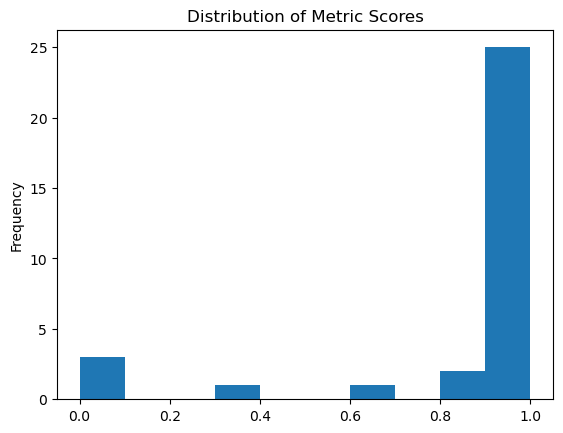

In [18]:
df_results[df_results["metric_name"]=="Answer Relevancy"].metric_score.plot(kind='hist', bins=10, title='Distribution of Metric Scores')

<Axes: title={'center': 'Distribution of Metric Scores'}, ylabel='Frequency'>

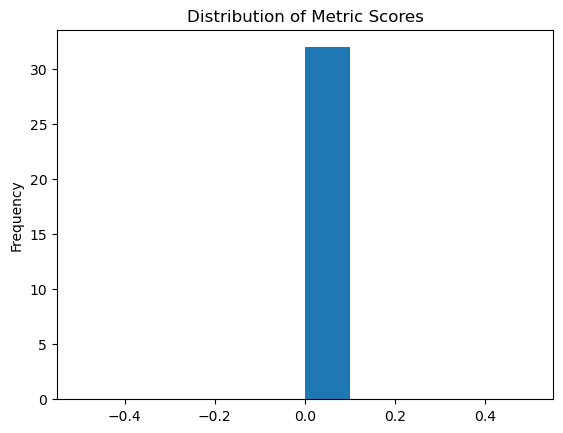

In [19]:
df_results[df_results["metric_name"]=="Bias"].metric_score.plot(kind='hist', bins=10, title='Distribution of Metric Scores')